# Time Series Forecasting with ARIMA

Author: Ethan Robert A. Casin


---

## Overview

In this notebook, students are expected to learn:
1. ARIMA forecasting;
2. Doing a time series split;
3. Baseline forecasting methods
4. Time series evaluation

---

In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from typing import Optional, Union
import statsmodels.api as sm


warnings.filterwarnings("ignore")

%load_ext autoreload
%autoreload 2

# ARIMA

$\text{ARIMA}$ stands for AutoRegressive Integrated Moving Average, which is a set of models that explain a time series using its own previous values from lags (AutoRegressive) and lagged errors (Moving Average) while considering stationarity corrected by differencing (opposite of Integration).

There are three (3) components of $\text{ARIMA}$:
    - AutoRegressive($\text{AR}(p)$): A model that uses the dependent relationship between an observation and some number of lagged observations.
    - Integrated ($\text{I}(d)$): The use of differencing in order to make the time series stationary.
    - Moving Average ($\text{MA}(q)$): A model that uses the dependency between an observation and a residual error from a moving average model applied to lagged observations.

In [2]:
from statsmodels.tsa.arima.model import ARIMA

The general form of $\text{ARIMA}(p, d, q)$ can be written as

\begin{equation*}
\left(1 - \sum_{i=1}^p\phi_i\mathbf{B}^i \right)\left(1 - \mathbf{B} \right)^dy_t = c + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i \right)\epsilon_t
\end{equation*}

Where $\mathbf{B}$ is the backshift operator, $c$ is a constant, $y_t$ is the observed value at time $t$, $\epsilon_t \sim N(0, 1)$ is white noise, and $\phi$ and $\theta$ are the coefficients for the autoregressive and moving average components, respectfully. This model's drift component can be defined by

\begin{equation*}
\mu = \frac{c}{1 - \sum\phi_i}
\end{equation*}

where $\mu$ is the average of the changes between consecutive observations.


---

**Derivation**

Recall that $\text{ARMA}(p, q)$ has the general form:

\begin{align*}
y_t &= c + \epsilon_t + \left(\sum_{i=1}^p\phi_i\mathbf{B}^i \right)y_t + \left(\sum_{i=1}^q\theta_i\mathbf{B}^i\right)\epsilon_t\\
\end{align*}

We can combine similar terms, resulting in

\begin{align*}
\left(1 - \sum_{i=1}^p\phi_i\mathbf{B}^i \right)y_t = c + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i \right)\epsilon_t
\end{align*}

Because we want to have differencing within the model, we can perform a $d$-th order difference on the autoregressive component. Recall that the goal of differencing is to convert a time series into a stationary time series. Therefore, we cannot do this on the moving average component as it is assumed to be stationary since these are errors. A $d$-th order difference on a timeseries is defined as 

\begin{align}
y_t^d = (1 - \mathbf{B})^dy_t
\end{align}

We can then perform differencing on $y_t \rightarrow y_t^d$ on our equation. Thus, we can rewrite $\text{ARMA}(p^d, q)$ as $\text{ARIMA}(p, d, q)$ to include differencing within its general form.


\begin{align*}
\left(1 - \sum_{i=1}^p\phi_i\mathbf{B}^i \right)y_t^d &= c + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i \right)\epsilon_t\\
\left(1 - \sum_{i=1}^p\phi_i\mathbf{B}^i \right)\left(1 - \mathbf{B} \right)^dy_t &= c + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i \right)\epsilon_t\\
\end{align*}

---

## Special Case 1: Autoregressive Model $\text{ARIMA}(p, 0, 0)$

If the series is stationary and autocorrelated, perhaps it can be predicted as a multiple of its own previous value plus a constant. Using the parameter set, we can rearrange our general equation to form the autoregressive model.

\begin{equation*}
y_t = c + \epsilon_t + \left(\sum_{i=1}^p\phi_i\mathbf{B}^i\right)y_t
\end{equation*}

Note that for the moving average component the lagged errors would be equal to zero, however because there is a constant $1$ the final result would yield an error term $\epsilon_t$.

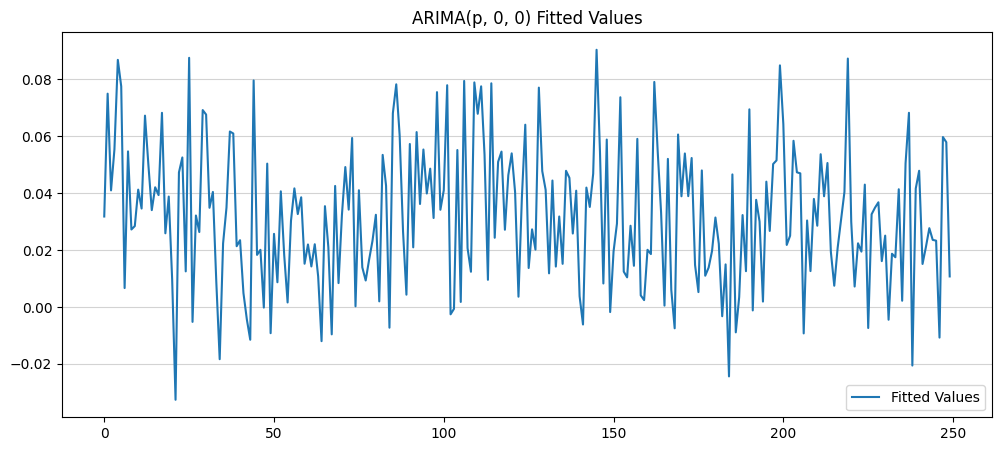

In [3]:
# Example 1: ARIMA(p, 0, 0) Special Case
# ------------------------------------------------------------------------------

# Given an arbitrary time series and the chosen ARIMA parameters

# ---------Adjust This Value---------
p = 1
# ---------Adjust This Value---------
d = 0
q = 0

params = (p, d, q)

np.random.seed(0)
time_series_length = 250
data = np.random.normal(0, 1, size=time_series_length)

# When fitting an ARIMA(p, 0, 0) model
arima = ARIMA(data, order=params)
fit = arima.fit()

# Then we can get the fitted values of our ARIMA model and plot it out
fitted_values = fit.fittedvalues

plt.figure(figsize=(12, 5))
plt.plot(fitted_values, label="Fitted Values")
plt.title("ARIMA(p, 0, 0) Fitted Values")
plt.legend()
plt.grid(axis="y", c="lightgray")
plt.show()

## Special Case 2: Moving Average Model $\text{ARIMA}(0, 0, q)$

If the time series is stationary but it is correlated to the errors of the previous values, then we can regress using the past forecast errors. We can therefore rewrite our general equation to fit our parameters.

\begin{equation*}
y_t = c + \left(1 + \sum_{i=1}^q\theta_i\mathbf{B}^i\right)\epsilon_t
\end{equation*}

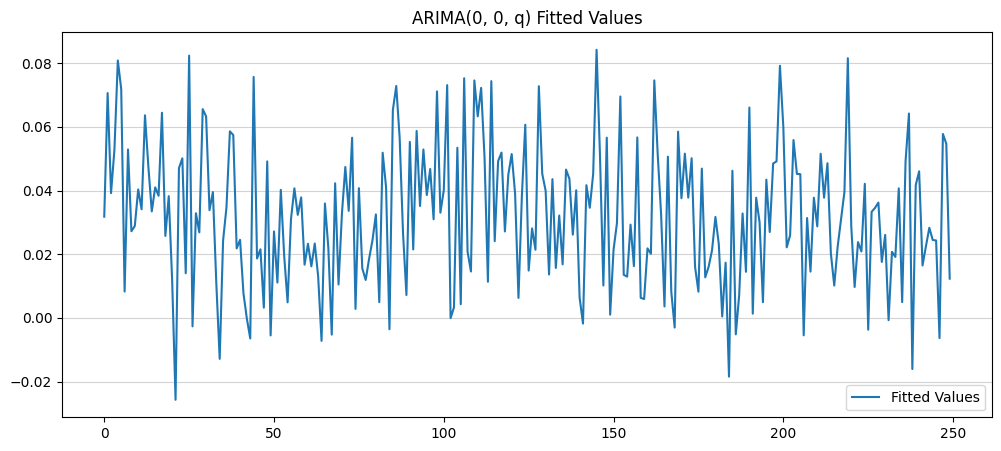

In [5]:
# Example 2: ARIMA(0, 0, q) Special Case
# ------------------------------------------------------------------------------

# Given an arbitrary time series and the chosen ARIMA parameters

p = 0
d = 0
# ---------Adjust This Value---------
q = 1
# ---------Adjust This Value---------

params = (p, d, q)

np.random.seed(0)
time_series_length = 250
data = np.random.normal(0, 1, size=time_series_length)

# When fitting an ARIMA(0, 0, q) model
arima = ARIMA(data, order=params)
fit = arima.fit()

# Then we can get the fitted values of our ARIMA model and plot it out
fitted_values = fit.fittedvalues

plt.figure(figsize=(12, 5))
plt.plot(fitted_values, label="Fitted Values")
plt.title("ARIMA(0, 0, q) Fitted Values")
plt.legend()
plt.grid(axis="y", c="lightgray")
plt.show()

## Special Case 3: Random Walk $\text{ARIMA}(0, 1, 0)$

If the series is non-stationary, then the simplest model we can use is a random walk. From our general equation, we can generate recreate a random walk with the mentioned parameters.

\begin{equation}
y_t = c + \epsilon_t + \mathbf{B}y_t
\end{equation}

Note that the constant $c$ is the drift term. Therefore, if we consider a typical random walk without drift we set $c=0$ resulting in 

\begin{equation}
y_t = \epsilon_t + \mathbf{B}y_t
\end{equation}

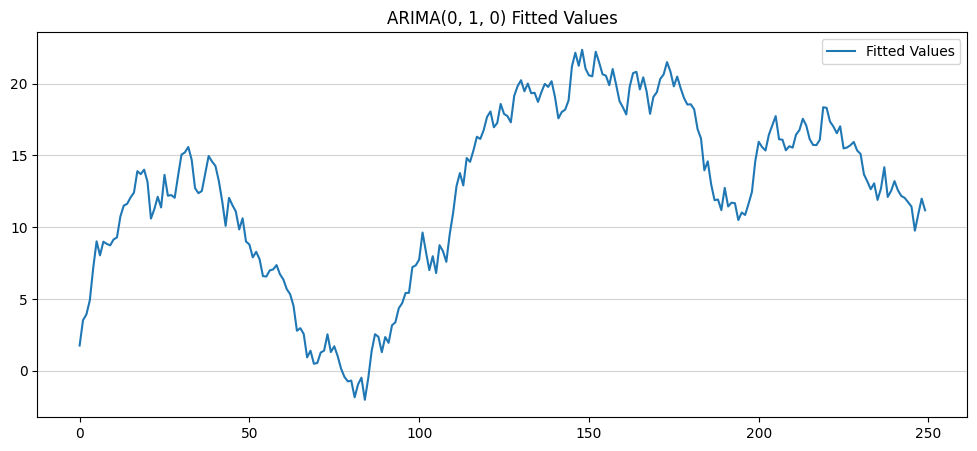

In [6]:
# Example 3: ARIMA(0, 1, 0) Special Case
# -----------------------------------------------------------------------------

# Given an arbitrary time series and the chosen ARIMA parameters

p = 0
d = 1
q = 0

params = (p, d, q)

np.random.seed(0)
time_series_length = 250
data = np.random.normal(0, 1, size=time_series_length)

# When fitting an ARIMA(0, 1, 0) model
arima_ar = ARIMA(data, order=params)
fit = arima_ar.fit()

# Then we can get the fitted values of our ARIMA model and plot it out
fitted_values = fit.fittedvalues

# statsmodels returns the first differenced results so we need to correct that
corrected_fitted_values = data[0] + fitted_values.cumsum()

plt.figure(figsize=(12, 5))
plt.plot(corrected_fitted_values, label="Fitted Values")
plt.title("ARIMA(0, 1, 0) Fitted Values")
plt.legend()
plt.grid(axis="y", c="lightgray")
plt.show()

# Tuning ARIMA

When creating an $\text{ARIMA}$ model, we need to explicitly indicate the parameters. Selecting the parameters $p,\ d,\ q$ can be difficult but there are several methods in automating this process. 

For this notebook, we demonstrate how we can use statistical tests, the Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) to make an educated guess regarding our model's parameters.

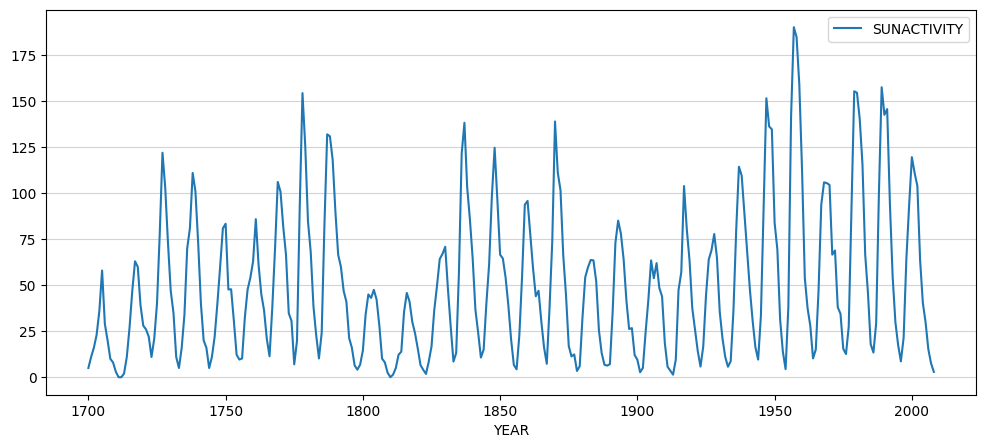

In [16]:
sunspot_data = sm.datasets.sunspots.load_pandas().data
sunspot_data["YEAR"] = sunspot_data["YEAR"].astype(int)
sunspot_data.set_index("YEAR", inplace=True)

# View the sample data
sunspot_data.plot(figsize=(12, 5))
plt.grid(axis="y", c="lightgray")
plt.show()

## Train-Test Split

To make our lives simpler for now, let's try to see some nuances in creating our training and test splits for evaluation. ARIMA and some of the statistical methods don't require that much fixing to work. 

Because our data is sequential, we can't really randomize our data when splitting. We also have to ensure we conserve the sequence of the data.

In [17]:
test_prop = 0.2 # we get the last 20% from our data
n_points = sunspot_data.shape[0]
test_pts = round(n_points * test_prop)

train = sunspot_data.iloc[:-test_pts]
test = sunspot_data.iloc[-test_pts:]

We'll see in the next lecture how this splitting could potentially change.

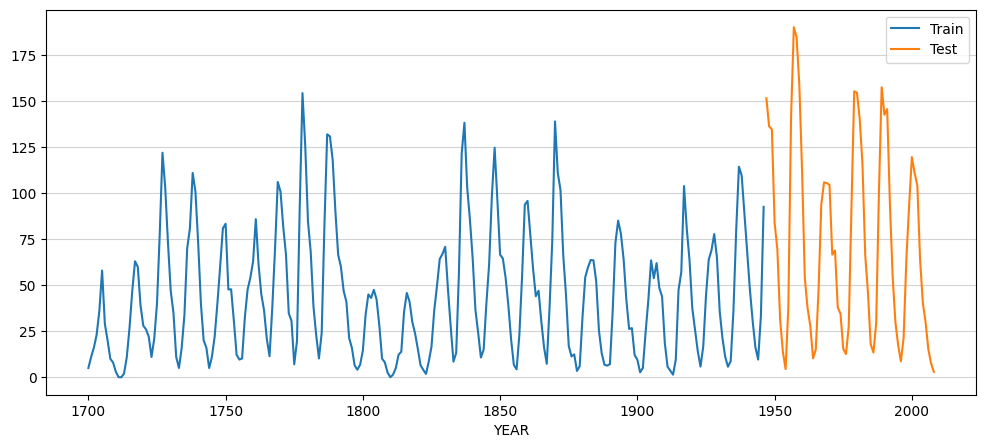

In [18]:
fig, ax = plt.subplots(figsize=(12,5))

train.plot(ax=ax)
test.plot(ax=ax)

plt.legend(["Train", "Test"])
plt.grid(axis="y", c="lightgray")
plt.show()

## Finding the optimal $d$ parameter

An important assumption in $\text{ARIMA}$ models is stationarity. As we have seen, doing differencing for our time series ensures that we make our input stationary. The quickest way to determine the best $d$-th order is to use the Augmented-Dickey Fuller (ADF) and the Kwaitkowski-Phillips-Schmidt-Shin (KPSS) tests. 

We can also look into the ACF and PACF plots, but we can focus on using these tests to simplify the discussion.

For cycles, sometimes differencing is not enough. Let us set $d$ arbitrarily for now. For $d=3$, the third derivative is not usual. As a judgement case, let us set d to one

In [19]:
from statsmodels.tsa.stattools import adfuller, kpss

In [20]:
p_value = 0.5

# let's get our p-values already
adf_res = adfuller(train)[1]
kpss_res = kpss(train)[1]

print("ADF Result:", "Stationary" if adf_res < p_value else "Not Stationary")
print("KPSS Result:", "Not Stationary" if kpss_res < p_value else "Stationary")

ADF Result: Stationary
KPSS Result: Not Stationary


Recall that if ADF is telling us that our time series is stationary, while KPSS is showing us that it's not we can simply do differencing to our time series to make it stationary.

In [21]:
differenced_ts = train.diff() 

# You would drop some rows when you do differencing
display(differenced_ts.head())

differenced_ts = differenced_ts.dropna()

,SUNACTIVITY
YEAR,
1700,NaN
1701,6.0
1702,5.0
1703,7.0
1704,13.0


In [22]:
adf_res = adfuller(differenced_ts)[1]
kpss_res = kpss(differenced_ts)[1]

print("ADF Result:", "Stationary" if adf_res < p_value else "Not Stationary")
print("KPSS Result:", "Not Stationary" if kpss_res < p_value else "Stationary")

ADF Result: Stationary
KPSS Result: Not Stationary


We can do another round of differencing

In [23]:
differenced2_ts = differenced_ts.diff().dropna()

adf_res = adfuller(differenced2_ts)[1]
kpss_res = kpss(differenced2_ts)[1]

print("ADF Result:", "Stationary" if adf_res < p_value else "Not Stationary")
print("KPSS Result:", "Not Stationary" if kpss_res < p_value else "Stationary")

ADF Result: Stationary
KPSS Result: Not Stationary


In [24]:
differenced3_ts = differenced2_ts.diff().dropna()

adf_res = adfuller(differenced3_ts)[1]
kpss_res = kpss(differenced3_ts)[1]

print("ADF Result:", "Stationary" if adf_res < p_value else "Not Stationary")
print("KPSS Result:", "Not Stationary" if kpss_res < p_value else "Stationary")

ADF Result: Stationary
KPSS Result: Not Stationary


Now this seems to be a tough data to crack, but in general we often stop at $d=3$ or $d=4$ when differencing our time series. 

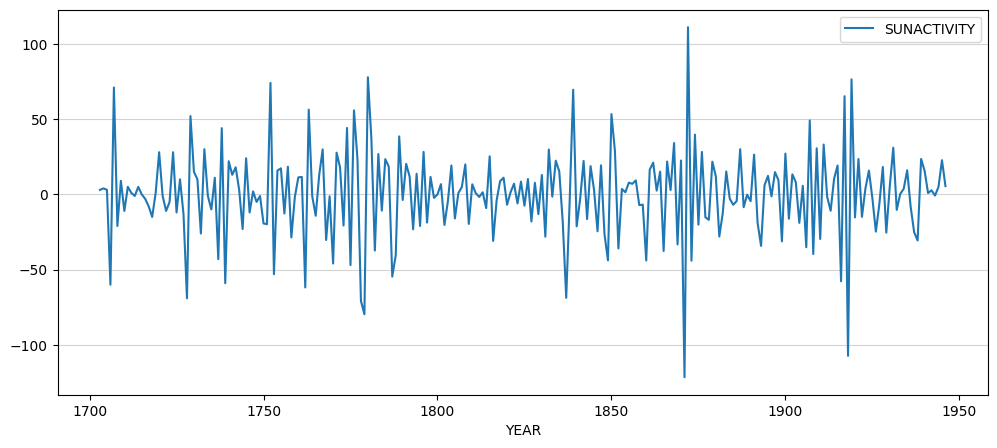

In [25]:
# Let's see what it looks like


differenced3_ts.plot(figsize=(12, 5))
plt.grid(axis="y", c="lightgray")
plt.show()

In general, you may need to do multiple rounds of differencing to make the time series stationary. There may be cases where you may need to do seasonal differencing or detrending. As you can see, we can automate finding the optimal $d$ by automating these two tests. 

In practice, $d > 2$ is rare and usually indicates that we would need to do a different preprocessing method. Some examples are log transformations, FFT, seasonal differencing, etc.
For now, let's make a judgement call and say that $d=1$.

## Optimizing $p$

To optimize for our autoregressive term $p$ we need to use the PACF plot. As the name suggests, the PACF plot shows the pure correlation between lags by removing the influence of other lags. You can think of it as a direct measurement between $y_t$ and $y_{t-2}$ ($y_t \rightarrow y_{t-2}$) instead of having the correlation affected by $y_{t-1}$, i.e., $y_{t-2} \rightarrow y_{t-1} \rightarrow y_t$.

We'll perform this on the differenced time series.

for a rule of thumb, once you see any point where it is within the band, STAHP. Do not do this because you do not want to introduce noise to the model. The moment you have a drop-off point, get only the previous.

the blue band tells you that anything within this band is just white noise

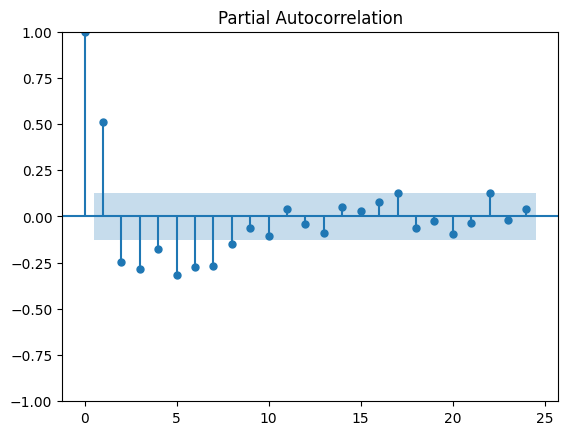

In [26]:
pacf_res = plot_pacf(differenced_ts)

We can see that our correlation suddenly drops to 0 after 8 lags. Therefore, we can say that it is significant up to 8 lags. This makes $p=8$ our optimal value for the autoregression model.

## Optimizing $q$

Similar to finding the best $p$ value, we can rely on the autocorrelation plot to find our best $q$. Note that we would still be using our differenced time series

for the MA, we use ACF to get all the past errors

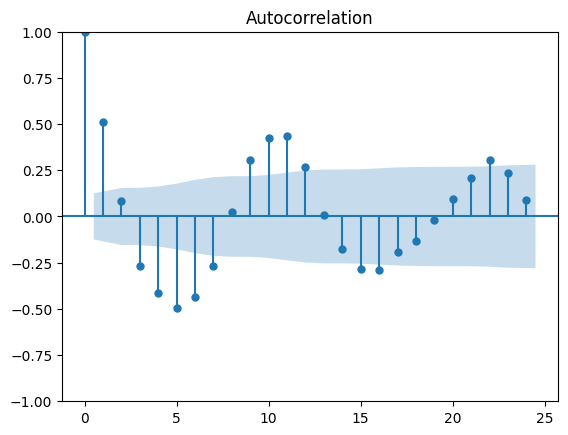

In [27]:
acf_res = plot_acf(differenced_ts)

If we inspect the ACF plot, we can see that it is significant up to lag 1. Therefore, $q=1$ for our moving average component. You may also notice that there is a seasonal component for every 11 lags. In this dataset, it is known that sunspot activity has a seasonal / cyclical nature every 11 years. For the purpose of our discussion, let's ignore the seasonality for now but know that we can conduct seasonal differencing should we choose to do so.

fitted values is for the training set

residual diagnostics for time series. For any ARIMA model, we can just get the residual function. The assumption is that the residuals is from gaussian distribution or a noise. If they do follow a noise, then it implies that the parameters for the ARIMA model is good. If it does not work, then it means you can tune your ARIMA a little bit better

MSE: 194.40


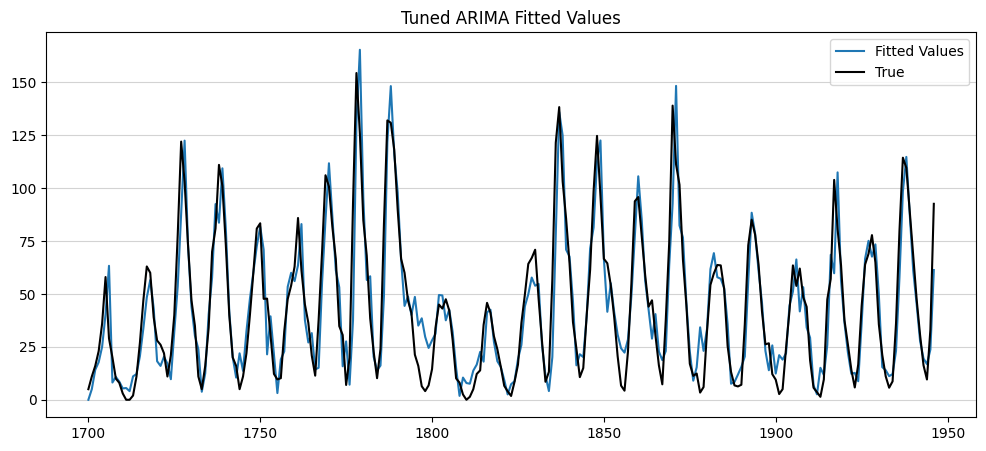

In [30]:
# Example 4: ARIMA(8, 1, 1) Optimal Model
# -----------------------------------------------------------------------------

# Given the sunspot activity time series and the chosen ARIMA parameters

p = 8
d = 1
q = 1

params = (p, d, q)

# When fitting an ARIMA model using the best parameters
arima_ar = ARIMA(train, order=params)
sun_fit = arima_ar.fit()

# Then we can get the fitted values of our ARIMA model and plot it out
sun_fitted_values = sun_fit.fittedvalues

print("=" * 50)
print(f"MSE: {sun_fit.mse:.2f}")
print("=" * 50)

plt.figure(figsize=(12, 5))
plt.plot(sun_fitted_values, label="Fitted Values")
plt.plot(train, c="black", label="True")
plt.title("Tuned ARIMA Fitted Values")
plt.legend()
plt.grid(axis="y", c="lightgray")
plt.show()

We can also look at the residuals of our model. Ideally, residuals in time series should be i.i.d drawn from a normal distribution.

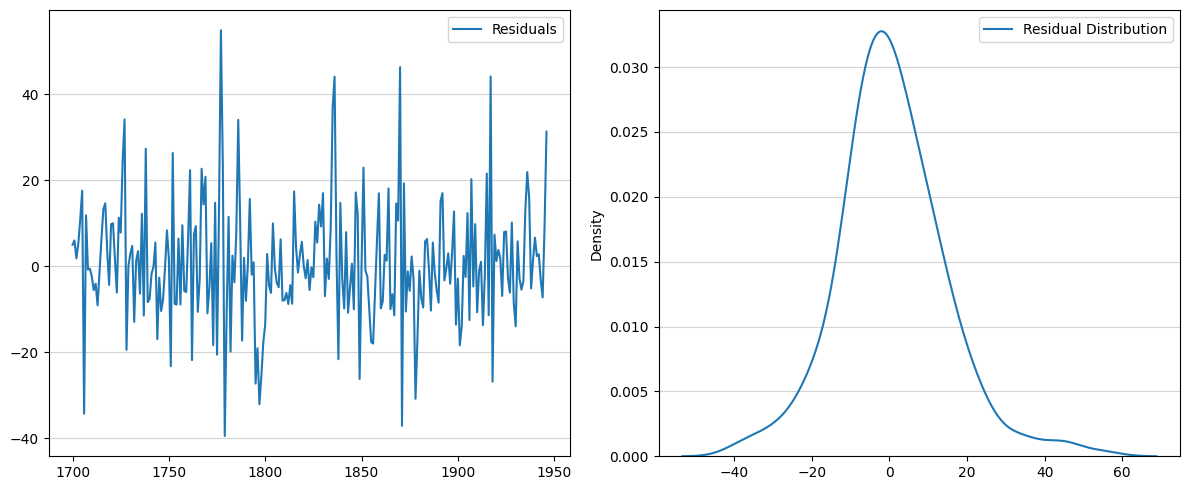

In [31]:
sunspot_residuals = sun_fit.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(sunspot_residuals, label="Residuals")
ax[0].legend()
ax[0].grid(axis="y", c="lightgray")

sns.kdeplot(sunspot_residuals, ax=ax[1], label="Residual Distribution")
ax[1].legend()
ax[1].grid(axis="y", c="lightgray")

plt.tight_layout()

# Forecasting with ARIMA

Now that we have our "trained", also known as, "fitted" model, we can now try to forecast the future $n$ steps in our time series. Let's use the mean squared error for our metric

In [32]:
from sklearn.metrics import mean_squared_error

MSE: 1485.90


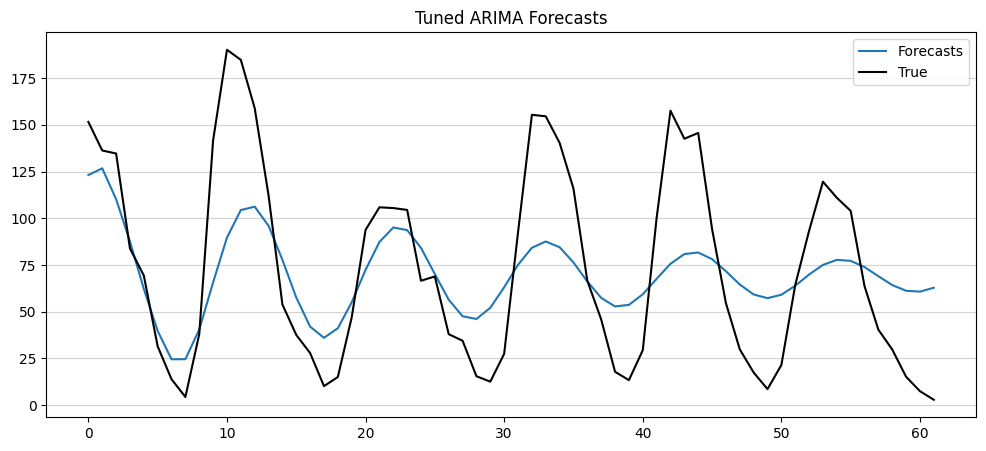

In [33]:
# we just want to forecast the next `test_pts` steps
# recall that `test_pts` is simply an integer showing you how many points
# are present in the test set. It doesn't contain any information about our test set
forecasts = sun_fit.forecast(steps=test_pts) 

print(f"MSE: {mean_squared_error(test.values.flatten(), forecasts):.2f}")

plt.figure(figsize=(12, 5))
plt.plot(forecasts.values, label="Forecasts")
plt.plot(test.values.flatten(), c="black", label="True")
plt.title("Tuned ARIMA Forecasts")
plt.legend()
plt.grid(axis="y", c="lightgray")
plt.show()

a problem with ARIMA is that still under the hood, it is still a linear model, which assumes that each lag to be independent. Because we have sequential data, past values actually affect future values. Thus, ARIMA breaks a few things, and as time goes forward, it gets less and less accurate. Moreover, it tends to flatten over time.  

Wold's Theorem
For only covariate-starionary (basic stationary). Basically, it says that it can be repsented as:
$y = \beta_0 + \sum_{i=1}^{N} \omega_i x_i + \epsilon$

the first is AR and second is MA

---

**Question**: Do you notice anything in particular with ARIMA? Try forecasting and plotting out your forecasts for a larger `step` size in `forecast`. What do you notice?

---

In this notebook, we've explored how to use ARIMA and how to use it for forecasting. In our next lecture, we'll get to learn some of the baseline methods we use in forecasting and even how to use the ML models we've learned in ML1 in time series.